## XGBoost Regression

XGBoost (Extreme Gradient Boosting) is an optimized implementation of the Gradient Boosting algorithm. It builds Decision Trees sequentially, where each new tree learns from the errors of the previous trees while using advanced optimization techniques for faster training and better performance.

### Why XGBoost?

Gradient Boosting provides high accuracy but can be slow on large datasets. XGBoost improves Gradient Boosting by introducing optimized tree construction, regularization, parallel processing, and efficient memory usage.

### Key Features

- Optimized Gradient Boosting implementation.
- Sequential learning from previous errors.
- Built-in regularization.
- Faster training.
- Feature Importance support.
- Handles large datasets efficiently.

### Important Parameters

- **n_estimators:** Number of trees.
- **learning_rate:** Controls each tree's contribution.
- **max_depth:** Maximum depth of each tree.

### Advantages

- High prediction accuracy.
- Fast and memory efficient.
- Built-in regularization.
- Industry-standard algorithm.
- Widely used in Kaggle competitions.

### Disadvantages

- More hyperparameters to tune.
- Can overfit if not configured properly.
- Less interpretable than Linear Regression.

### Real-World Applications

- House Price Prediction
- Fraud Detection
- Credit Risk Analysis
- Medical Diagnosis
- Customer Churn Prediction
- Sales Forecasting

In [31]:
import xgboost
print(xgboost.__version__)

3.3.0


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

import joblib

In [4]:
df = pd.read_csv("../data/housing.csv")

In [5]:
X = df.drop(["Price", "Address"], axis=1)
y = df["Price"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [25]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

In [26]:
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("MAE :", mae)
print("RMSE:", rmse)
print("R² :", r2)

MAE : 85379.78445089998
RMSE: 107149.87030598812
R² : 0.9066823885804915


In [27]:
joblib.dump(
    xgb_model,
    "../models/xgboost_model.pkl"
)

['../models/xgboost_model.pkl']

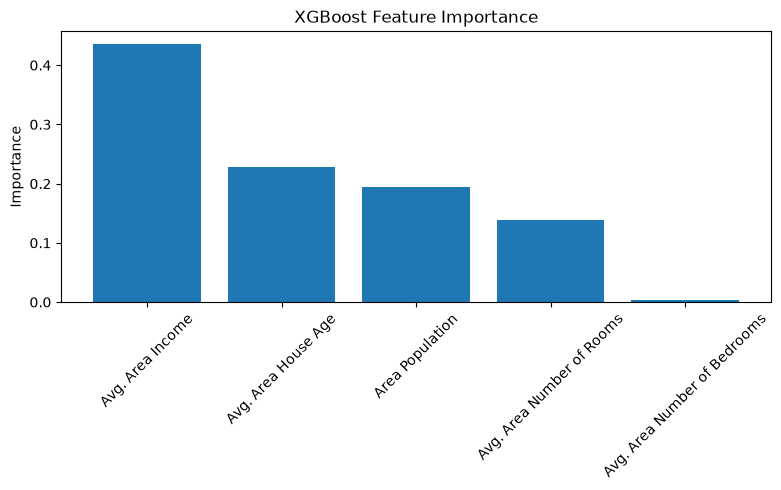

In [28]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance
plt.figure(figsize=(8,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xticks(rotation=45)

plt.title("XGBoost Feature Importance")

plt.ylabel("Importance")

plt.tight_layout()

plt.show()